<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/Minst_dataset_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras import layers,models

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.datasets import mnist

In [3]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train,X_test=X_train/255.0,X_test/255.0

In [6]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64,activation='softmax'))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 232,000 (906.25 KB)

 Trainable params: 232,000 (906.25 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
histroy=model.fit(
    X_train,y_train,
    batch_size=128,
    epochs=10,
    verbose=1,
    validation_data=(X_test,y_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8861 - loss: 0.3887 - val_accuracy: 0.9765 - val_loss: 0.0678
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9685 - loss: 0.1048 - val_accuracy: 0.9860 - val_loss: 0.0444
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9776 - loss: 0.0778 - val_accuracy: 0.9883 - val_loss: 0.0343
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9826 - loss: 0.0614 - val_accuracy: 0.9890 - val_loss: 0.0316
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9835 - loss: 0.0547 - val_accuracy: 0.9903 - val_loss: 0.0284
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9854 - loss: 0.0474 - val_accuracy: 0.9923 - val_loss: 0.0240
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9879 - loss: 0.0407 - val_accuracy: 0.9916 - val_loss: 0.0262
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9898 - loss: 0.0349 - val_accuracy: 

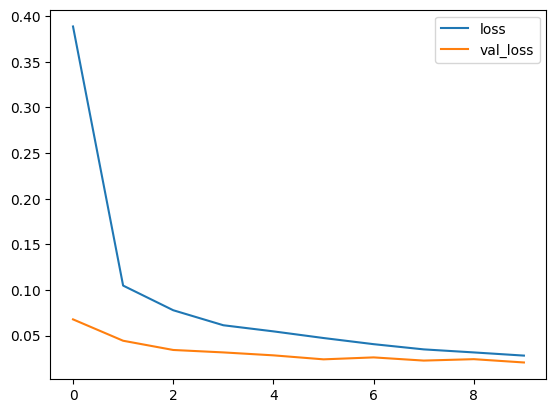

In [11]:
import matplotlib.pyplot as plt
plt.plot(histroy.history['loss'],label='loss')
plt.plot(histroy.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

In [15]:
test_loss,test_acc=model.evaluate(X_test,y_test)
print("the test accuracy is:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9929 - loss: 0.0206
the test accuracy is: 0.992900013923645


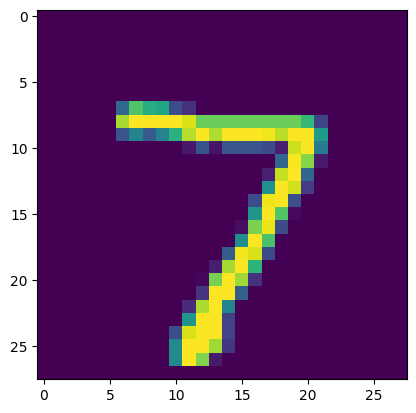

In [13]:
plt.imshow(X_test[0])

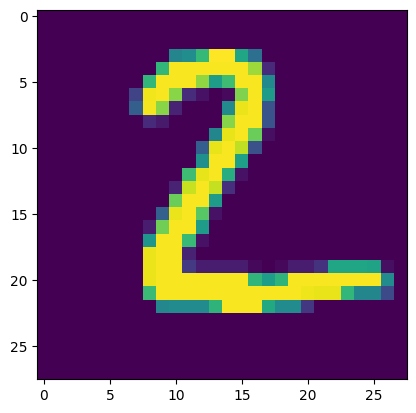

In [16]:
plt.imshow(X_test[1])

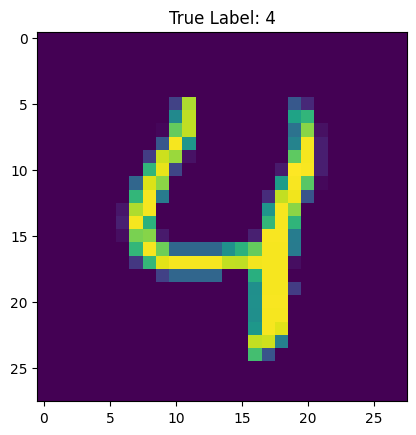

In [19]:
# Choose an image from the test set (e.g., the 5th image)
image_index = 4

# Display the image
plt.imshow(X_test[image_index])
plt.title(f"True Label: {y_test[image_index]}")
plt.show()

In [18]:
# Reshape the image for prediction (add batch dimension and channel dimension)
import numpy as np
image_to_predict = np.expand_dims(X_test[image_index], axis=0)
image_to_predict = np.expand_dims(image_to_predict, axis=-1)

# Get the model's prediction
predictions = model.predict(image_to_predict)
predicted_label = np.argmax(predictions[0])

print(f"The model predicts this image is: {predicted_label}")
print(f"The actual label is: {y_test[image_index]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step
The model predicts this image is: 4
The actual label is: 4


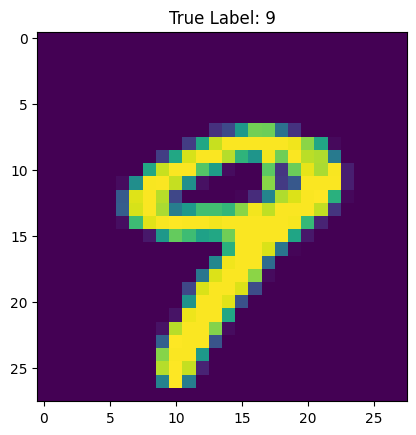

In [20]:
image_index=9
plt.imshow(X_test[image_index])
plt.title(f"True Label: {y_test[image_index]}")
plt.show()